In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("Employee_Attrition.csv")

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome(KM),Education,EducationField,...,RelationshipSatisfaction,StandardWorkingHours,StockOptionLevel,TotalExperience(Years),TrainingsLastYear,WorkLifeBalance,YearsatCompany,YearsinCurrentRole,YearsSincePromotion,YearsWithCurrManager
0,VK2970,19,18-25,Yes,Travel_Rarely,230,Administration,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,VK3020,19,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,VK4580,19,18-25,Yes,Travel-Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,VK7280,19,18-25,No,Non-Travel,287,Administration,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,VK8290,19,18-25,Yes,Non-Travel,247,Administration,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (1480, 37)

Columns:
Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome(KM)', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'SalarySlab', 'HourlyRate',
       'NumCompaniesWorked', 'Over18', 'OverTime', 'SalaryHike %',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardWorkingHours',
       'StockOptionLevel', 'TotalExperience(Years)', 'TrainingsLastYear',
       'WorkLifeBalance', 'YearsatCompany', 'YearsinCurrentRole',
       'YearsSincePromotion', 'YearsWithCurrManager'],
      dtype='str')

Data Types:
EmpID                           str
Age                           int64
AgeGroup                        str
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department  

In [4]:
print(df.isna().sum())

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome(KM)         0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
HourlyRate                   0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
SalaryHike %                 0
PerformanceRating            0
RelationshipSatisfaction     0
StandardWorkingHours         0
StockOptionLevel             0
TotalExperience(Years)       0
TrainingsLastYear            0
WorkLife

In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [6]:
print(df["YearsWithCurrManager"].isna().sum())

61


In [7]:
median_value = df["YearsWithCurrManager"].median()

df["YearsWithCurrManager"] = df["YearsWithCurrManager"].fillna(median_value)

print("Missing values after cleaning:")
print(df["YearsWithCurrManager"].isna().sum())

Missing values after cleaning:
0


In [8]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (1480, 37)

Missing values:
EmpID                       0
Age                         0
AgeGroup                    0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome(KM)        0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
SalarySlab                  0
HourlyRate                  0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
SalaryHike %                0
PerformanceRating           0
RelationshipSatisfaction    0
StandardWorkingHours        0
StockOptionLevel            0
TotalExperience(Years)      0
TrainingsLastYear          

In [9]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (1478, 37)
Duplicate rows: 0


In [10]:
categorical_columns = df.select_dtypes(include="object").columns
numerical_columns = df.select_dtypes(include="number").columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['EmpID', 'AgeGroup', 'Attrition', 'BusinessTravel', 'Department',
       'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'SalarySlab',
       'Over18', 'OverTime'],
      dtype='str')

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome(KM)', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'HourlyRate', 'NumCompaniesWorked', 'SalaryHike %', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardWorkingHours', 'StockOptionLevel',
       'TotalExperience(Years)', 'TrainingsLastYear', 'WorkLifeBalance',
       'YearsatCompany', 'YearsinCurrentRole', 'YearsSincePromotion',
       'YearsWithCurrManager'],
      dtype='str')


C:\Users\91630\AppData\Local\Temp\ipykernel_1952\1517525779.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [11]:
print("EmployeeCount:")
print(df["EmployeeCount"].value_counts())

print("\nOver18:")
print(df["Over18"].value_counts())

print("\nStandardWorkingHours:")
print(df["StandardWorkingHours"].value_counts())

EmployeeCount:
EmployeeCount
1    1478
Name: count, dtype: int64

Over18:
Over18
Y    1478
Name: count, dtype: int64

StandardWorkingHours:
StandardWorkingHours
80    1478
Name: count, dtype: int64


In [12]:
df = df.drop(columns=["EmployeeCount", "Over18", "StandardWorkingHours"])

print("New dataset shape:", df.shape)
print("\nRemaining columns:")
print(df.columns)

New dataset shape: (1478, 34)

Remaining columns:
Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome(KM)', 'Education', 'EducationField',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'SalarySlab', 'HourlyRate', 'NumCompaniesWorked',
       'OverTime', 'SalaryHike %', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalExperience(Years)', 'TrainingsLastYear', 'WorkLifeBalance',
       'YearsatCompany', 'YearsinCurrentRole', 'YearsSincePromotion',
       'YearsWithCurrManager'],
      dtype='str')


In [13]:
attrition_count = df["Attrition"].value_counts()

print(attrition_count)

Attrition
No     1239
Yes     239
Name: count, dtype: int64


In [14]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print("Attrition Rate:", round(attrition_rate, 2), "%")

Attrition Rate: 16.17 %


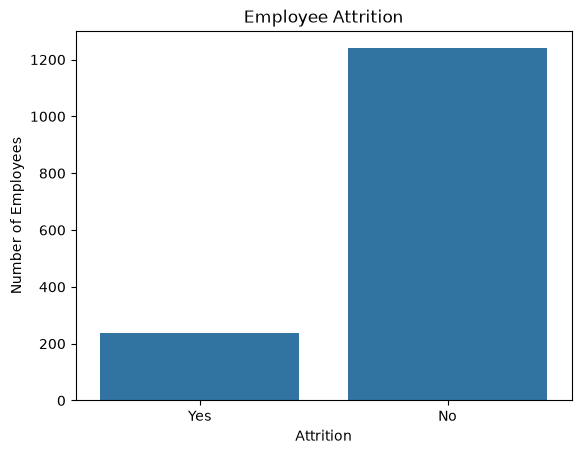

In [15]:
sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [16]:
# Total employees in each department
total_department = df.groupby("Department").size()

# Employees who left in each department
department_attrition = df[df["Attrition"] == "Yes"].groupby("Department").size()

# Calculate attrition rate
department_attrition_rate = (department_attrition / total_department) * 100

# Combine everything into one table
department_analysis = pd.DataFrame({
    "Total Employees": total_department,
    "Attrition": department_attrition,
    "Attrition Rate (%)": department_attrition_rate
})

print(department_analysis)

                 Total Employees  Attrition  Attrition Rate (%)
Department                                                     
Administration               425         88           20.705882
Finance                       24          3           12.500000
Human Resources               39          9           23.076923
IT                           169         30           17.751479
Marketing                     67         10           14.925373
Operations                   540         45            8.333333
Sales                        214         54           25.233645


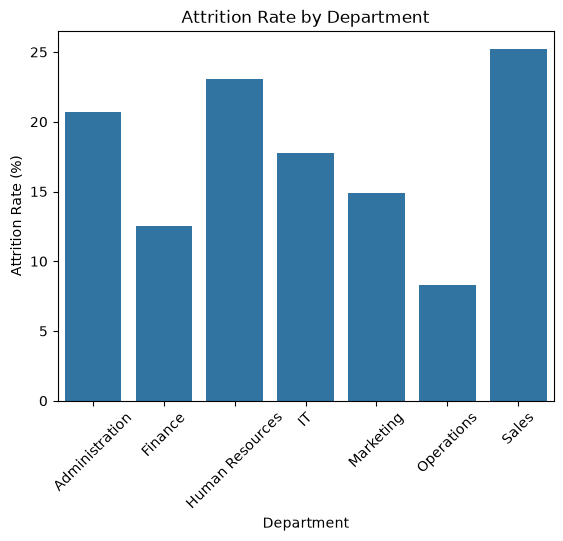

In [17]:
sns.barplot(
    x=department_analysis.index,
    y=department_analysis["Attrition Rate (%)"]
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [18]:
# Total employees in each job role
total_jobrole = df.groupby("JobRole").size()

# Employees who left in each job role
jobrole_attrition = df[df["Attrition"] == "Yes"].groupby("JobRole").size()

# Calculate attrition rate
jobrole_attrition_rate = (jobrole_attrition / total_jobrole) * 100

# Combine into one table
jobrole_analysis = pd.DataFrame({
    "Total Employees": total_jobrole,
    "Attrition": jobrole_attrition,
    "Attrition Rate (%)": jobrole_attrition_rate
})

print(jobrole_analysis.sort_values("Attrition Rate (%)", ascending=False))

                           Total Employees  Attrition  Attrition Rate (%)
JobRole                                                                  
Sales Representative                    84         34           40.476190
Laboratory Technician                  259         61           23.552124
Human Resources                         52         12           23.076923
Sales Executive                        329         58           17.629179
Research Scientist                     293         48           16.382253
Manufacturing Director                 146         10            6.849315
Healthcare Representative              133          9            6.766917
Manager                                102          5            4.901961
Research Director                       80          2            2.500000


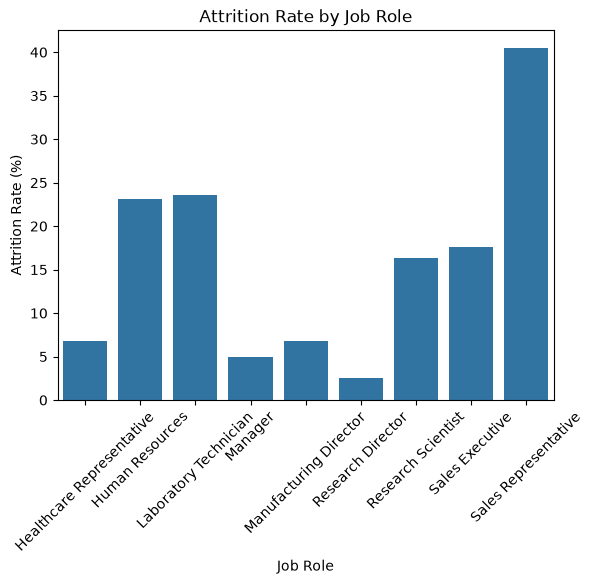

In [19]:
sns.barplot(
    data=jobrole_analysis.reset_index(),
    x="JobRole",
    y="Attrition Rate (%)"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [20]:
# Total employees by overtime
total_overtime = df.groupby("OverTime").size()

# Employees who left by overtime
overtime_attrition = df[df["Attrition"] == "Yes"].groupby("OverTime").size()

# Calculate attrition rate
overtime_attrition_rate = (overtime_attrition / total_overtime) * 100

# Combine into one table
overtime_analysis = pd.DataFrame({
    "Total Employees": total_overtime,
    "Attrition": overtime_attrition,
    "Attrition Rate (%)": overtime_attrition_rate
})

print(overtime_analysis)

          Total Employees  Attrition  Attrition Rate (%)
OverTime                                                
No                   1059        109           10.292729
Yes                   419        130           31.026253


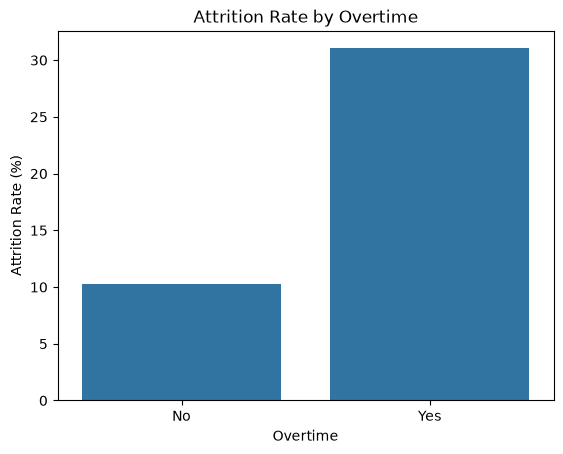

In [21]:
sns.barplot(
    data=overtime_analysis.reset_index(),
    x="OverTime",
    y="Attrition Rate (%)"
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [22]:
# Total employees by gender
total_gender = df.groupby("Gender").size()

# Employees who left by gender
gender_attrition = df[df["Attrition"] == "Yes"].groupby("Gender").size()

# Calculate attrition rate
gender_attrition_rate = (gender_attrition / total_gender) * 100

# Combine into one table
gender_analysis = pd.DataFrame({
    "Total Employees": total_gender,
    "Attrition": gender_attrition,
    "Attrition Rate (%)": gender_attrition_rate
})

print(gender_analysis)

        Total Employees  Attrition  Attrition Rate (%)
Gender                                                
Female              590         88           14.915254
Male                888        151           17.004505


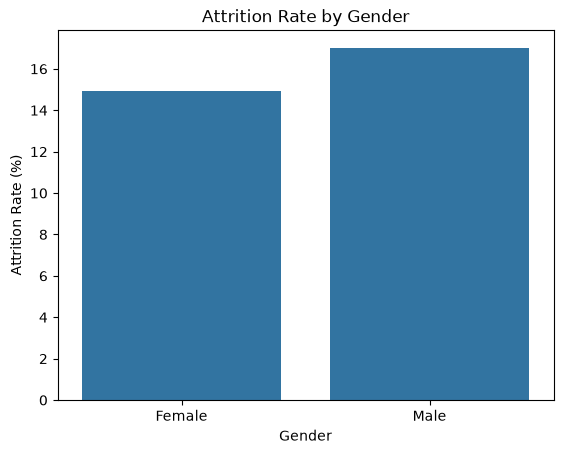

In [23]:
sns.barplot(
    data=gender_analysis.reset_index(),
    x="Gender",
    y="Attrition Rate (%)"
)

plt.title("Attrition Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [24]:
job_satisfaction_analysis = df.groupby("Attrition")["JobSatisfaction"].mean()

print(job_satisfaction_analysis)

Attrition
No     2.772397
Yes    2.451883
Name: JobSatisfaction, dtype: float64


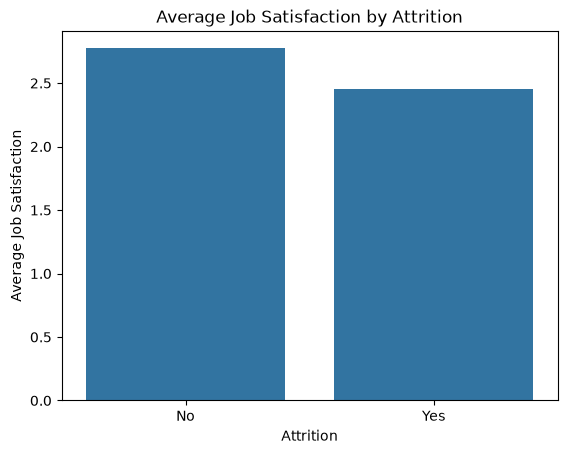

In [25]:
sns.barplot(
    x=job_satisfaction_analysis.index,
    y=job_satisfaction_analysis.values
)

plt.title("Average Job Satisfaction by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Job Satisfaction")
plt.show()

In [26]:
income_analysis = df.groupby("Attrition")["MonthlyIncome"].mean()

print(income_analysis)

Attrition
No     49356.871671
Yes    50330.548117
Name: MonthlyIncome, dtype: float64


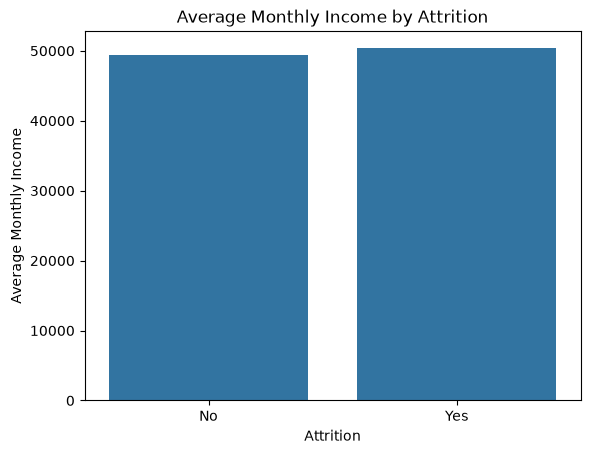

In [27]:
sns.barplot(
    x=income_analysis.index,
    y=income_analysis.values
)

plt.title("Average Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Monthly Income")
plt.show()

In [28]:
# Total employees by age group
total_agegroup = df.groupby("AgeGroup").size()

# Employees who left by age group
agegroup_attrition = df[df["Attrition"] == "Yes"].groupby("AgeGroup").size()

# Calculate attrition rate
agegroup_attrition_rate = (agegroup_attrition / total_agegroup) * 100

# Combine into one table
agegroup_analysis = pd.DataFrame({
    "Total Employees": total_agegroup,
    "Attrition": agegroup_attrition,
    "Attrition Rate (%)": agegroup_attrition_rate
})

print(agegroup_analysis.sort_values("Attrition Rate (%)", ascending=False))

          Total Employees  Attrition  Attrition Rate (%)
AgeGroup                                                
18-25                 123         45           36.585366
26-35                 609        116           19.047619
55+                    47          8           17.021277
46-55                 228         27           11.842105
36-45                 471         43            9.129512


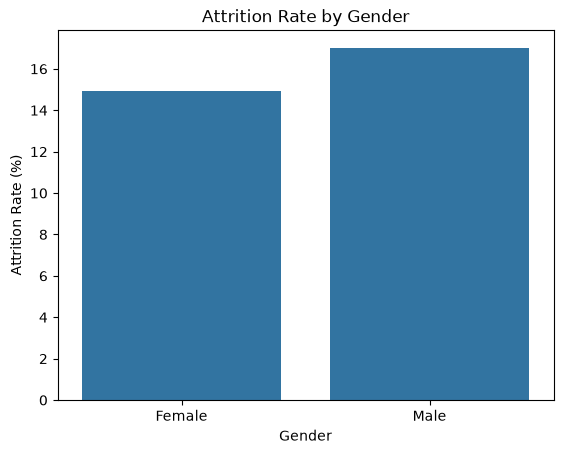

In [29]:
sns.barplot(
    data=gender_analysis.reset_index(),
    x="Gender",
    y="Attrition Rate (%)"
)

plt.title("Attrition Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Attrition Rate (%)")
plt.show()

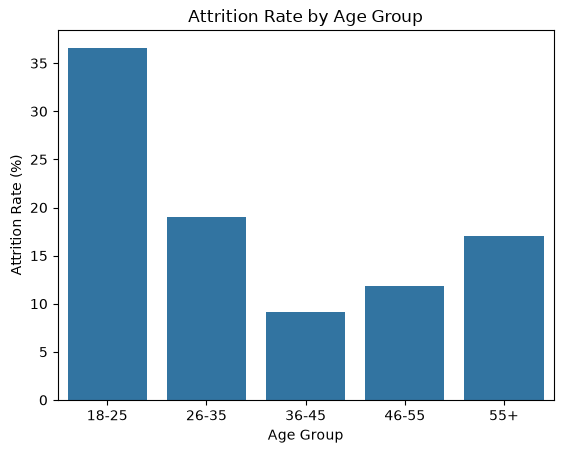

In [30]:
sns.barplot(
    data=agegroup_analysis.reset_index(),
    x="AgeGroup",
    y="Attrition Rate (%)"
)

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [31]:
# Fix inconsistent BusinessTravel category
df["BusinessTravel"] = df["BusinessTravel"].replace(
    "TravelRarely",
    "Travel_Rarely"
)

# Check the categories again
print(df["BusinessTravel"].value_counts())

BusinessTravel
Travel_Rarely        1050
Travel-Frequently     277
Non-Travel            151
Name: count, dtype: int64


In [32]:
# Total employees by business travel
total_travel = df.groupby("BusinessTravel").size()

# Employees who left by business travel
travel_attrition = df[df["Attrition"] == "Yes"].groupby("BusinessTravel").size()

# Calculate attrition rate
travel_attrition_rate = (travel_attrition / total_travel) * 100

# Combine into one table
travel_analysis = pd.DataFrame({
    "Total Employees": total_travel,
    "Attrition": travel_attrition,
    "Attrition Rate (%)": travel_attrition_rate
})

print(travel_analysis.sort_values("Attrition Rate (%)", ascending=False))

                   Total Employees  Attrition  Attrition Rate (%)
BusinessTravel                                                   
Travel-Frequently              277         70           25.270758
Travel_Rarely                 1050        157           14.952381
Non-Travel                     151         12            7.947020


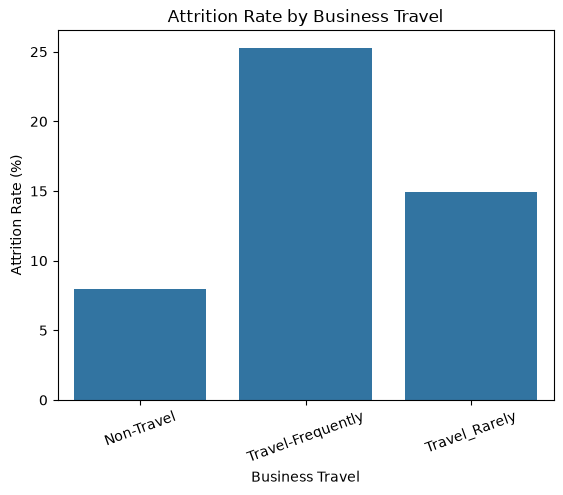

In [33]:
sns.barplot(
    data=travel_analysis.reset_index(),
    x="BusinessTravel",
    y="Attrition Rate (%)"
)

plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [34]:
# Total employees by work-life balance
total_wlb = df.groupby("WorkLifeBalance").size()

# Employees who left by work-life balance
wlb_attrition = df[df["Attrition"] == "Yes"].groupby("WorkLifeBalance").size()

# Calculate attrition rate
wlb_attrition_rate = (wlb_attrition / total_wlb) * 100

# Combine into one table
wlb_analysis = pd.DataFrame({
    "Total Employees": total_wlb,
    "Attrition": wlb_attrition,
    "Attrition Rate (%)": wlb_attrition_rate
})

print(wlb_analysis)

                 Total Employees  Attrition  Attrition Rate (%)
WorkLifeBalance                                                
1                             81         25           30.864198
2                            348         59           16.954023
3                            895        128           14.301676
4                            154         27           17.532468


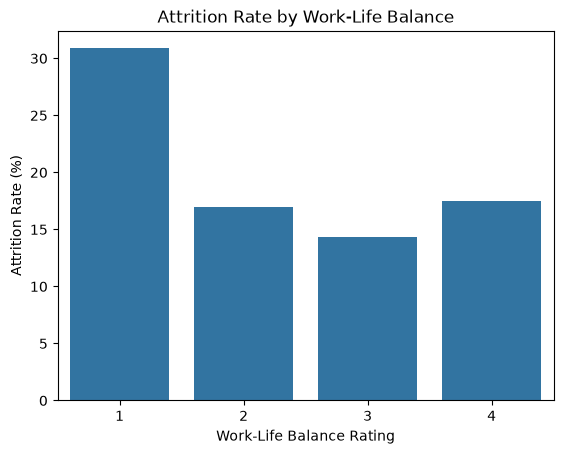

In [35]:
sns.barplot(
    data=wlb_analysis.reset_index(),
    x="WorkLifeBalance",
    y="Attrition Rate (%)"
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [36]:
# Detect outliers using IQR

Q1 = df["MonthlyIncome"].quantile(0.25)
Q3 = df["MonthlyIncome"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["MonthlyIncome"] < lower_bound) |
    (df["MonthlyIncome"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", outliers.shape[0])

Q1: 24342.5
Q3: 74519.5
IQR: 50177.0
Lower Bound: -50923.0
Upper Bound: 149785.0
Number of Outliers: 0


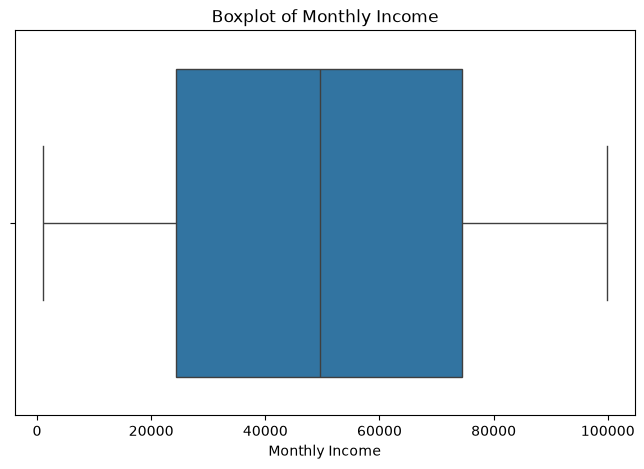

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["MonthlyIncome"])

plt.title("Boxplot of Monthly Income")
plt.xlabel("Monthly Income")

plt.show()

In [38]:
# Check outliers using IQR for numerical columns

numerical_columns = df.select_dtypes(include="number").columns

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(column, ":", len(outliers), "outliers")

Age : 0 outliers
DailyRate : 0 outliers
DistanceFromHome(KM) : 0 outliers
Education : 0 outliers
EmployeeNumber : 0 outliers
EnvironmentSatisfaction : 0 outliers
JobInvolvement : 0 outliers
JobLevel : 0 outliers
JobSatisfaction : 0 outliers
MonthlyIncome : 0 outliers
HourlyRate : 0 outliers
NumCompaniesWorked : 52 outliers
SalaryHike % : 0 outliers
PerformanceRating : 227 outliers
RelationshipSatisfaction : 0 outliers
StockOptionLevel : 85 outliers
TotalExperience(Years) : 63 outliers
TrainingsLastYear : 240 outliers
WorkLifeBalance : 0 outliers
YearsatCompany : 105 outliers
YearsinCurrentRole : 21 outliers
YearsSincePromotion : 108 outliers
YearsWithCurrManager : 13 outliers


## Outlier Analysis

Outliers were checked in numerical columns using the Interquartile Range (IQR) method.

Some potential outliers were identified in variables such as Number of Companies Worked, Performance Rating, Trainings Last Year, Years at Company, and Years Since Promotion.

These values were retained because they may represent legitimate employee characteristics rather than data-entry errors.


# Key Insights

1. Overall attrition rate is 16.17%.

2. Sales has the highest department attrition rate at 25.23%.

3. Sales Representatives have the highest job-role attrition rate at 40.48%.

4. Employees who work overtime have a higher attrition rate of 31.03%.

5. Male employees have a slightly higher attrition rate of 17.00%.

6. Employees who left had lower average job satisfaction (2.45) than employees who stayed (2.77).

7. Employees aged 18-25 have the highest attrition rate at 36.59%.

8. Employees who travel frequently have the highest attrition rate at 25.27%.

9. Employees with Work-Life Balance rating 1 have the highest attrition rate at 30.86%.